In [ ]:
# ============================================================
# CELL 1: Verify GPU is active
# ============================================================
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
else:
    print("WARNING: No GPU found. Go to Runtime > Change runtime type > T4 GPU")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4
Memory: 15.64 GB


In [ ]:
import torch

# ============================================================
# CELL 2: Install all required libraries
# ============================================================
!pip install transformers datasets emoji scikit-learn kagglehub[pandas-datasets] -q

print("All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 17.0 MB/s eta 0:00:00
All libraries installed successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 3: Setup project directory for local storage
# ============================================================
from google.colab import drive
import os

# Create a folder for your project in the Colab environment
SAVE_PATH = '/content/emoji_sentiment_research_local/'
os.makedirs(SAVE_PATH, exist_ok=True)

print("Models will be saved to local Colab environment at:", SAVE_PATH)

Models will be saved to local Colab environment at: /content/emoji_sentiment_research_local/


In [ ]:
import os

# Create a folder for your project in Google Drive
SAVE_PATH_GD = '/content/drive/MyDrive/emoji_sentiment_research_gdrive/'
os.makedirs(SAVE_PATH_GD, exist_ok=True)

# Update the global SAVE_PATH to point to Google Drive
SAVE_PATH = SAVE_PATH_GD

print("Models will be saved to Google Drive at:", SAVE_PATH)

Models will be saved to Google Drive at: /content/drive/MyDrive/emoji_sentiment_research_gdrive/


In [ ]:
# ============================================================
# CELL 4: Import all libraries
# ============================================================
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import emoji
import re
from collections import Counter

from transformers import BertTokenizer, BertModel
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set device — uses GPU if available
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# ============================================================
# CELL 5: Load Uploaded 'dataset.csv' with 40/20/40 Split
# ============================================================

csv_path = '/content/dataset.csv'

if os.path.exists(csv_path):
    try:
        # Using utf-8-sig to handle BOM and 'replace' errors to keep emojis intact even with malformed EOF
        df_raw = pd.read_csv(csv_path, encoding='utf-8-sig', on_bad_lines='skip', engine='python', encoding_errors='replace')
        print(f"Loaded {csv_path} successfully using UTF-8-SIG with error replacement.")
    except Exception as e:
        print(f"Critical load failure. Error: {e}")
else:
    print(f"ERROR: {csv_path} not found.")

sentiment_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
rename_dict = {'comment': 'text', 'sentiment': 'label'}
df_raw = df_raw.rename(columns=rename_dict)

if 'label' in df_raw.columns and df_raw['label'].dtype == object:
    df_raw['label'] = df_raw['label'].str.strip().str.title().map(sentiment_map)

df_raw = df_raw.dropna(subset=['text', 'label'])
df_raw['label'] = df_raw['label'].astype(int)

# Remove duplicate records
initial_rows = len(df_raw)
df_raw.drop_duplicates(subset=['text', 'label'], inplace=True)
print(f"Removed {initial_rows - len(df_raw)} duplicate records. Remaining: {len(df_raw)}")

# Split data: 40% for test, 60% for train_val
train_val, test_df = train_test_split(df_raw, test_size=0.40, random_state=42, stratify=df_raw['label'])

# From train_val (60% of total), split for train (40% of total) and val (20% of total)
# 20% of total / 60% of total = 1/3 ~ 0.3333
val_relative_size = 0.20 / 0.60 # 20% validation from the original dataset, relative to the 60% train_val set
train_df, val_df = train_test_split(train_val, test_size=val_relative_size, random_state=42, stratify=train_val['label'])

print(f"Total rows: {len(df_raw)}")
print(f"Train rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows: {len(test_df)}")
print("Sample with correctly decoded emojis:")
display(df_raw[df_raw['text'].str.contains(r'[^\x00-\x7F]', na=False)].head())

Loaded /content/dataset.csv successfully using UTF-8-SIG with error replacement.
Removed 3735 duplicate records. Remaining: 96265
Total rows: 96265
Train rows: 38505
Validation rows: 19254
Test rows: 38506
Sample with correctly decoded emojis:


,id,category,text,label
0,1,Food,The spice level tastes fine 🔍🔍🔍🔍🔍,1
1,2,Online Goods,this order waste of money 🩹🩹🩹🩹,0
2,3,Clothing,the sizing 🔥🔥🔥🔥🔥 obsessed with the color,2
3,4,Food,This delivery way too salty 🗑️🙄💢⛈️🥀,0
4,5,TV Shows,The plot twist I am obsessed with this 💯💯💯💯💯💯💯,2


In [ ]:
import emoji
import re

# ============================================================
# CELL 6: Updated Preprocessing functions to handle complex symbols
# ============================================================

def extract_text_only(text):
    """Remove all emojis, keep only words"""
    cleaned = emoji.replace_emoji(str(text), replace='')
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned if cleaned else "[empty]"

def extract_emojis_only(text):
    """Extract only emojis, convert to text descriptions"""
    # Use emoji.emoji_list for more robust detection
    emoji_list = emoji.emoji_list(str(text))
    if not emoji_list:
        return "[no_emoji]"
    return ' '.join(emoji.demojize(e['emoji']) for e in emoji_list)

def extract_combined(text):
    return str(text)

# Test on a known emoji string
test_tweet = "Love this! 😍✨"
print("Original:", test_tweet)
print("Extracted:", extract_emojis_only(test_tweet))

Original: Love this! 😍✨
Extracted: :smiling_face_with_heart-eyes: :sparkles:


In [ ]:
# ============================================================
# CELL 7: Preprocess and Save Dataframes
# ============================================================

def process_df(df):
    df['raw_text'] = df['text']
    df['text_only'] = df['text'].apply(extract_text_only)
    df['emoji_only'] = df['text'].apply(extract_emojis_only)
    df['combined'] = df['text'].apply(extract_combined)
    return df[['raw_text', 'text_only', 'emoji_only', 'combined', 'label']]

print("Processing splits...")
train_df = process_df(train_df.copy())
val_df = process_df(val_df.copy())
test_df = process_df(test_df.copy())

# Save locally
train_df.to_csv(SAVE_PATH + 'train_df.csv', index=False)
test_df.to_csv(SAVE_PATH + 'test_df.csv', index=False)
print("\nDataFrames processed and saved locally!")
display(train_df.head(2))

Processing splits...

DataFrames processed and saved locally!


,raw_text,text_only,emoji_only,combined,label
18686,the sizing looks like the picture 🆗🆗🆗🆗🆗🆗🆗,the sizing looks like the picture,:OK_button: :OK_button: :OK_button: :OK_button...,the sizing looks like the picture 🆗🆗🆗🆗🆗🆗🆗,1
10318,the meal pretty standard 🤏☕☕📥📦🍿,the meal pretty standard,:pinching_hand: :hot_beverage: :hot_beverage: ...,the meal pretty standard 🤏☕☕📥📦🍿,1


In [ ]:
# ============================================================
# CELL 8: Build emoji vocabulary for the emoji model
# ============================================================

# Collect all unique emoji tokens from the training set
all_emoji_tokens = []
for text in train_df['emoji_only']:
    tokens = text.split()
    all_emoji_tokens.extend(tokens)

# Build vocabulary: token → index
token_counts = Counter(all_emoji_tokens)
# Keep tokens that appear at least twice
vocab_tokens = [tok for tok, cnt in token_counts.items() if cnt >= 2]

# Index 0 = padding, Index 1 = unknown
emoji_vocab = {'[PAD]': 0, '[UNK]': 1}
for i, tok in enumerate(vocab_tokens, start=2):
    emoji_vocab[tok] = i

EMOJI_VOCAB_SIZE = len(emoji_vocab)
MAX_EMOJI_LEN    = 20  # max number of emojis per tweet

print(f"Emoji vocabulary size: {EMOJI_VOCAB_SIZE}")
print(f"Max emoji sequence length: {MAX_EMOJI_LEN}")
print("\nSample vocab entries:")
for k, v in list(emoji_vocab.items())[:10]:
    print(f"  {k} → {v}")

Emoji vocabulary size: 96
Max emoji sequence length: 20

Sample vocab entries:
  [PAD] → 0
  [UNK] → 1
  :OK_button: → 2
  :pinching_hand: → 3
  :hot_beverage: → 4
  :inbox_tray: → 5
  :package: → 6
  :popcorn: → 7
  :cloud: → 8
  :face_with_monocle: → 9


In [ ]:
# ============================================================
# CELL 9: PyTorch Dataset classes for all 3 pipelines
# ============================================================

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 128

class TextDataset(Dataset):
    """Pipeline A — text only, encoded with BERT tokenizer"""
    def __init__(self, df):
        self.texts  = df['text_only'].tolist()
        self.labels = df['label'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            max_length=MAX_TEXT_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

class EmojiDataset(Dataset):
    """Pipeline B — emoji only, encoded with our custom vocab"""
    def __init__(self, df):
        self.emojis = df['emoji_only'].tolist()
        self.labels = df['label'].tolist()

    def __len__(self):
        return len(self.labels)

    def encode_emojis(self, emoji_str):
        tokens  = emoji_str.split()[:MAX_EMOJI_LEN]
        indices = [emoji_vocab.get(t, 1) for t in tokens]  # 1 = UNK
        # Pad to MAX_EMOJI_LEN
        indices += [0] * (MAX_EMOJI_LEN - len(indices))
        return torch.tensor(indices, dtype=torch.long)

    def __getitem__(self, idx):
        return {
            'emoji_ids': self.encode_emojis(self.emojis[idx]),
            'label'    : torch.tensor(self.labels[idx], dtype=torch.long)
        }

class CombinedDataset(Dataset):
    """Pipeline C — text + emojis together"""
    def __init__(self, df):
        self.texts  = df['combined'].tolist()
        self.emojis = df['emoji_only'].tolist()
        self.labels = df['label'].tolist()
        self.emoji_ds = EmojiDataset(df)
        self.text_ds  = TextDataset(df)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text_item  = self.text_ds[idx]
        emoji_item = self.emoji_ds[idx]
        return {
            'input_ids'     : text_item['input_ids'],
            'attention_mask': text_item['attention_mask'],
            'emoji_ids'     : emoji_item['emoji_ids'],
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Dataset classes defined successfully!")

# Create DataLoaders
BATCH_SIZE = 32

train_text_loader  = DataLoader(TextDataset(train_df),    batch_size=BATCH_SIZE, shuffle=True)
val_text_loader    = DataLoader(TextDataset(val_df),      batch_size=BATCH_SIZE)
test_text_loader   = DataLoader(TextDataset(test_df),     batch_size=BATCH_SIZE)

train_emoji_loader = DataLoader(EmojiDataset(train_df),   batch_size=BATCH_SIZE, shuffle=True)
val_emoji_loader   = DataLoader(EmojiDataset(val_df),     batch_size=BATCH_SIZE)
test_emoji_loader  = DataLoader(EmojiDataset(test_df),    batch_size=BATCH_SIZE)

train_comb_loader  = DataLoader(CombinedDataset(train_df),batch_size=BATCH_SIZE, shuffle=True)
val_comb_loader    = DataLoader(CombinedDataset(val_df),  batch_size=BATCH_SIZE)
test_comb_loader   = DataLoader(CombinedDataset(test_df), batch_size=BATCH_SIZE)

print(f"Train batches (text) : {len(train_text_loader)}")
print(f"Train batches (emoji): {len(train_emoji_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset classes defined successfully!
Train batches (text) : 1204
Train batches (emoji): 1204


In [ ]:
# ============================================================
# CELL 10: Define all 3 deep learning models
# ============================================================

# ── Pipeline A: Text-Only Model ──────────────────────────────
class TextSentimentModel(nn.Module):
    def __init__(self, hidden_dim=256, output_dim=3, dropout=0.3):
        super().__init__()
        self.bert    = BertModel.from_pretrained('bert-base-uncased')
        # Freeze BERT layers — only train the classifier head
        for param in self.bert.parameters():
            param.requires_grad = False

        # Input → Hidden → Output
        self.classifier = nn.Sequential(
            nn.Linear(768, hidden_dim),   # Input layer  (768 = BERT size)
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)  # Output layer (3 classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs  = self.bert(input_ids=input_ids,
                             attention_mask=attention_mask)
        cls_token = outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.classifier(cls_token)


# ── Pipeline B: Emoji-Only Model ───────────────────────────────
class EmojiSentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64,
                 hidden_dim=128, output_dim=3, dropout=0.3):
        super().__init__()
        # Input layer: embedding converts indices to vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Hidden layer: LSTM captures emoji sequence patterns
        self.lstm      = nn.LSTM(embed_dim, hidden_dim,
                                 batch_first=True, bidirectional=True)
        self.dropout   = nn.Dropout(dropout)
        # Output layer: 3 classes
        # bidirectional LSTM → hidden_dim * 2
        self.fc        = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, emoji_ids):
        embedded          = self.embedding(emoji_ids)
        _, (hidden, _)    = self.lstm(embedded)
        # Concatenate forward + backward hidden states
        hidden_cat        = torch.cat([hidden[-2], hidden[-1]], dim=1)
        out               = self.dropout(hidden_cat)
        return self.fc(out)


# ── Pipeline C: Combined Model ────────────────────────────────
class CombinedSentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64,
                 hidden_dim=256, output_dim=3, dropout=0.3):
        super().__init__()
        # Text branch (BERT)
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        self.text_fc = nn.Linear(768, 128)

        # Emoji branch (Embedding + LSTM)
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm       = nn.LSTM(embed_dim, 64,
                                  batch_first=True, bidirectional=True)
        self.emoji_fc   = nn.Linear(128, 128)

        # Combined hidden layer
        self.combined   = nn.Sequential(
            nn.Linear(256, hidden_dim),  # 128 text + 128 emoji = 256
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, input_ids, attention_mask, emoji_ids):
        # Text branch
        bert_out  = self.bert(input_ids=input_ids,
                              attention_mask=attention_mask)
        text_feat = torch.relu(self.text_fc(
                        bert_out.last_hidden_state[:, 0, :]))

        # Emoji branch
        embedded       = self.embedding(emoji_ids)
        _, (hidden, _) = self.lstm(embedded)
        hidden_cat     = torch.cat([hidden[-2], hidden[-1]], dim=1)
        emoji_feat     = torch.relu(self.emoji_fc(hidden_cat))

        # Merge both branches → output
        merged = torch.cat([text_feat, emoji_feat], dim=1)
        return self.combined(merged)


# Instantiate all models and move to GPU
text_model  = TextSentimentModel().to(DEVICE)
emoji_model = EmojiSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)
comb_model  = CombinedSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)

# Count trainable parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Text model  trainable params: {count_params(text_model):,}")
print(f"Emoji model trainable params: {count_params(emoji_model):,}")
print(f"Combined    trainable params: {count_params(comb_model):,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text model  trainable params: 197,635
Emoji model trainable params: 205,571
Combined    trainable params: 254,211


In [ ]:
# ============================================================
# CELL 11: Training loop + evaluation function
# ============================================================

def train_epoch(model, loader, optimizer, criterion, pipeline='text'):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        optimizer.zero_grad()

        labels = batch['label'].to(DEVICE)

        if pipeline == 'text':
            outputs = model(
                batch['input_ids'].to(DEVICE),
                batch['attention_mask'].to(DEVICE)
            )
        elif pipeline == 'emoji':
            outputs = model(batch['emoji_ids'].to(DEVICE))
        else:  # combined
            outputs = model(
                batch['input_ids'].to(DEVICE),
                batch['attention_mask'].to(DEVICE),
                batch['emoji_ids'].to(DEVICE)
            )

        loss = criterion(outputs, labels)
        loss.backward()          # Backpropagation
        optimizer.step()         # Update weights

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, pipeline='text'):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in loader:
            labels = batch['label'].to(DEVICE)

            if pipeline == 'text':
                outputs = model(
                    batch['input_ids'].to(DEVICE),
                    batch['attention_mask'].to(DEVICE)
                )
            elif pipeline == 'emoji':
                outputs = model(batch['emoji_ids'].to(DEVICE))
            else:
                outputs = model(
                    batch['input_ids'].to(DEVICE),
                    batch['attention_mask'].to(DEVICE),
                    batch['emoji_ids'].to(DEVICE)
                )
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    avg_loss = total_loss / len(loader)
    return acc, f1, avg_loss, all_preds, all_labels

print("Training functions ready!")

Training functions ready!


In [ ]:
# ============================================================
# CELL 12: Train all 3 models and save locally
# ============================================================

# Ensure models are initialized
if 'text_model' not in globals():
    print("Initializing models...")
    text_model  = TextSentimentModel().to(DEVICE)
    emoji_model = EmojiSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)
    comb_model  = CombinedSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)

EPOCHS    = 5
LR        = 2e-4
criterion = nn.CrossEntropyLoss()

# Global results dict to store validation F1s for final summary
results = {}

# Mapping pipelines to their respective loaders
pipeline_configs = [
    ('text',     text_model,  train_text_loader,  val_text_loader),
    ('emoji',    emoji_model, train_emoji_loader, val_emoji_loader),
    ('combined', comb_model,  train_comb_loader,  val_comb_loader),
]

for pipeline, model, train_loader, val_loader in pipeline_configs:
    print(f"\n{'='*50}")
    print(f"Training Pipeline: {pipeline.upper()}")
    print(f"{'='*50}")

    optimizer    = Adam(model.parameters(), lr=LR)
    best_val_f1  = 0
    train_losses = []
    val_losses   = [] # Re-added val_losses

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, pipeline)
        val_acc, val_f1, val_loss, _, _ = evaluate(model, val_loader, pipeline) # val_loss is now captured

        train_losses.append(train_loss)
        val_losses.append(val_loss) # Store val_loss

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Val F1: {val_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}") # Re-added val_loss to print

        # Save best model locally
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(),
                       SAVE_PATH + f'best_{pipeline}_model.pth')
            print(f"  --> New best model saved (F1={val_f1:.4f})")

    results[pipeline] = {
        'train_losses': train_losses,
        'val_losses': val_losses, # Store val_losses in results
        'best_val_f1' : best_val_f1
    }

print("\nAll models trained and saved locally!")


Training Pipeline: TEXT
Epoch 1/5 | Loss: 0.2586 | Train Acc: 0.9241 | Val Acc: 1.0000 | Val F1: 1.0000 | Val Loss: 0.0173
  --> New best model saved (F1=1.0000)
Epoch 2/5 | Loss: 0.0549 | Train Acc: 0.9867 | Val Acc: 1.0000 | Val F1: 1.0000 | Val Loss: 0.0039
Epoch 3/5 | Loss: 0.0348 | Train Acc: 0.9901 | Val Acc: 1.0000 | Val F1: 1.0000 | Val Loss: 0.0013
Epoch 4/5 | Loss: 0.0260 | Train Acc: 0.9926 | Val Acc: 1.0000 | Val F1: 1.0000 | Val Loss: 0.0005
Epoch 5/5 | Loss: 0.0193 | Train Acc: 0.9941 | Val Acc: 1.0000 | Val F1: 1.0000 | Val Loss: 0.0005

Training Pipeline: EMOJI
Epoch 1/5 | Loss: 0.1520 | Train Acc: 0.9660 | Val Acc: 0.9940 | Val F1: 0.9940 | Val Loss: 0.0219
  --> New best model saved (F1=0.9940)
Epoch 2/5 | Loss: 0.0161 | Train Acc: 0.9933 | Val Acc: 0.9943 | Val F1: 0.9943 | Val Loss: 0.0123
  --> New best model saved (F1=0.9943)
Epoch 3/5 | Loss: 0.0156 | Train Acc: 0.9932 | Val Acc: 0.9943 | Val F1: 0.9943 | Val Loss: 0.0120
Epoch 4/5 | Loss: 0.0133 | Train Acc: 0.

### Training and Validation Loss Curves

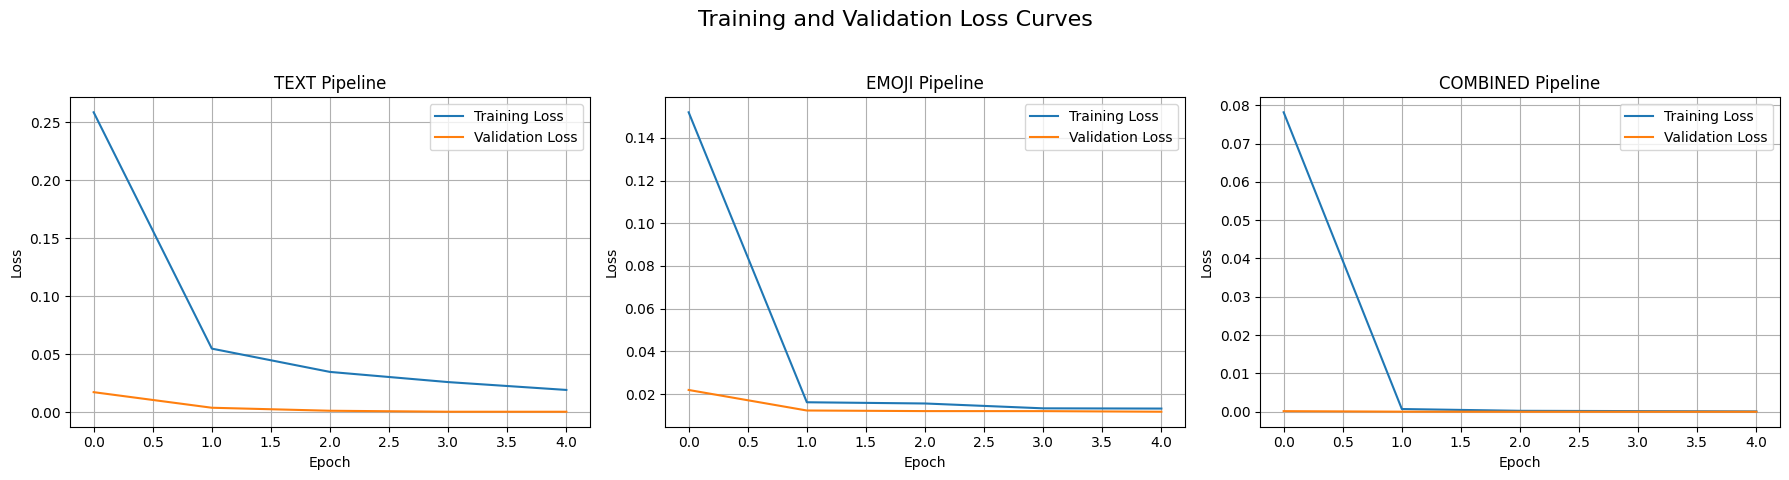

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CELL 12: Plotting Loss Curves
# ============================================================

if 'results' in globals() and results:
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
    if len(results) == 1:
        axes = [axes] # Make axes iterable if there's only one pipeline

    fig.suptitle('Training and Validation Loss Curves', fontsize=16)

    for i, (pipeline_name, data) in enumerate(results.items()):
        sns.lineplot(x=range(len(data['train_losses'])), y=data['train_losses'], ax=axes[i], label='Training Loss')
        sns.lineplot(x=range(len(data['val_losses'])), y=data['val_losses'], ax=axes[i], label='Validation Loss')
        axes[i].set_title(f'{pipeline_name.upper()} Pipeline')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel('Loss')
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No results available to plot. Please ensure Cell 12 (training) has been executed.")

In [ ]:
# ============================================================
# CELL 13: Load best models, run on test set, compare results
# ============================================================

CLASS_NAMES = ['Negative', 'Neutral', 'Positive']
final_results = {}

# Ensure models are initialized (if cell 10 was interrupted)
if 'text_model' not in globals():
    print("Re-initializing model structures...")
    text_model  = TextSentimentModel().to(DEVICE)
    emoji_model = EmojiSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)
    comb_model  = CombinedSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)

for pipeline, model, test_loader in [
    ('text',     text_model,  test_text_loader),
    ('emoji',    emoji_model, test_emoji_loader),
    ('combined', comb_model,  test_comb_loader),
]:
    try:
        # Load best saved weights locally
        model_path = SAVE_PATH + f'best_{pipeline}_model.pth'
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))

        # Fix: Add a placeholder for the `avg_loss` return value
        acc, f1, _, preds, labels = evaluate(model, test_loader, pipeline)
        final_results[pipeline] = {
            'accuracy': acc, 'f1': f1,
            'preds': preds, 'labels': labels
        }

        print(f"\n{'='*40}")
        print(f"Pipeline: {pipeline.upper()} — Test Results")
        print(f"{'='*40}")
        print(f"Accuracy : {acc:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print(classification_report(labels, preds, target_names=CLASS_NAMES))
    except FileNotFoundError:
        print(f"Warning: Could not find saved model at {model_path}. Please ensure Cell 12 finished training.")


Pipeline: TEXT — Test Results
Accuracy : 1.0000
F1 Score : 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00     12875
     Neutral       1.00      1.00      1.00     13065
    Positive       1.00      1.00      1.00     12566

    accuracy                           1.00     38506
   macro avg       1.00      1.00      1.00     38506
weighted avg       1.00      1.00      1.00     38506


Pipeline: EMOJI — Test Results
Accuracy : 0.9949
F1 Score : 0.9949
              precision    recall  f1-score   support

    Negative       1.00      0.98      0.99     12875
     Neutral       0.99      1.00      0.99     13065
    Positive       1.00      1.00      1.00     12566

    accuracy                           0.99     38506
   macro avg       1.00      0.99      0.99     38506
weighted avg       0.99      0.99      0.99     38506


Pipeline: COMBINED — Test Results
Accuracy : 1.0000
F1 Score : 1.0000
              precision    recal

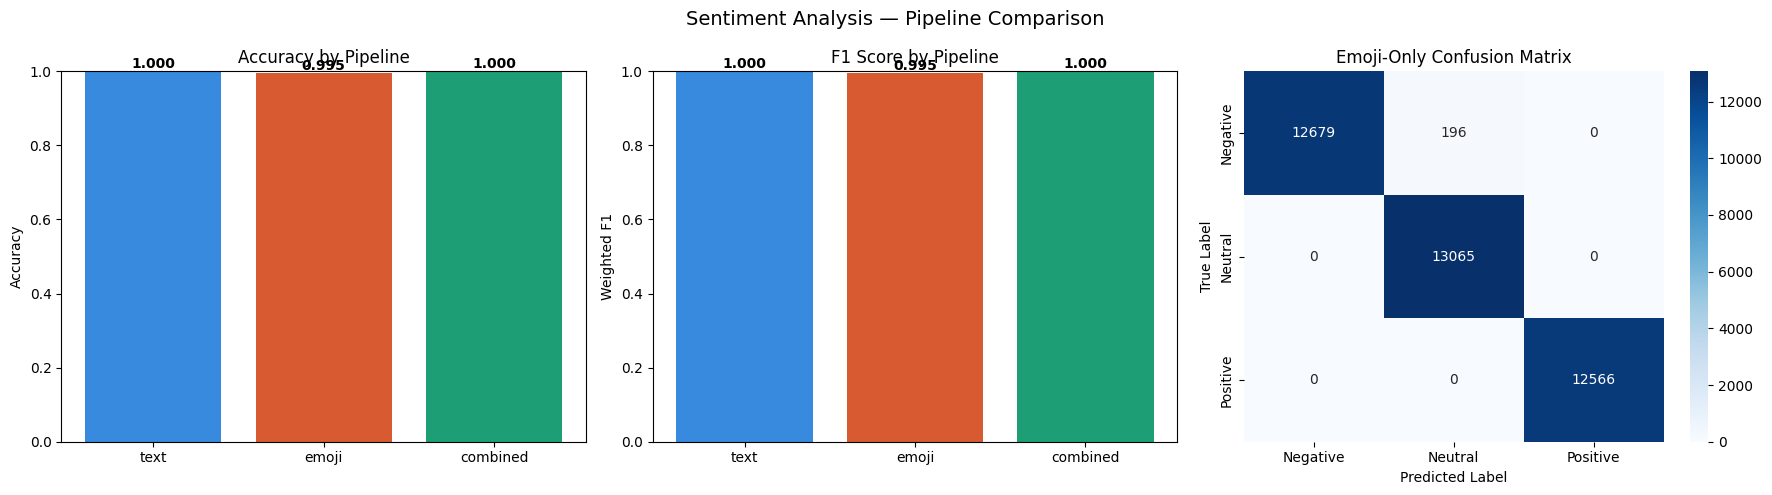

Chart saved locally!


In [ ]:
# ============================================================
# CELL 14: Visualize and compare all 3 pipelines
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

if 'final_results' in globals() and final_results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Sentiment Analysis — Pipeline Comparison', fontsize=14)

    pipelines  = list(final_results.keys())
    accuracies = [final_results[p]['accuracy'] for p in pipelines]
    f1_scores  = [final_results[p]['f1']       for p in pipelines]
    colors     = ['#378ADD', '#D85A30', '#1D9E75']

    # Chart 1: Accuracy comparison
    axes[0].bar(pipelines, accuracies, color=colors)
    axes[0].set_title('Accuracy by Pipeline')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(accuracies):
        axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

    # Chart 2: F1 Score comparison
    axes[1].bar(pipelines, f1_scores, color=colors)
    axes[1].set_title('F1 Score by Pipeline')
    axes[1].set_ylabel('Weighted F1')
    axes[1].set_ylim(0, 1)
    for i, v in enumerate(f1_scores):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

    # Chart 3: Confusion matrix for emoji-only
    if 'emoji' in final_results:
        cm = confusion_matrix(final_results['emoji']['labels'], final_results['emoji']['preds'])
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
        axes[2].set_title('Emoji-Only Confusion Matrix')
        axes[2].set_ylabel('True Label')
        axes[2].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(SAVE_PATH + 'comparison_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved locally!")
else:
    print("No results to plot. Please complete training (Cell 12) and evaluation (Cell 13) first.")

In [ ]:
# ============================================================
# CELL 15: Print final research summary table
# ============================================================
if 'final_results' in globals() and final_results:
    current_pipelines = list(final_results.keys())
    print("\n" + "="*55)
    print("       FINAL RESEARCH RESULTS SUMMARY")
    print("="*55)
    print(f"{'Pipeline':<12} {'Accuracy':>10} {'F1 Score':>10} {'Winner?':>10}")
    print("-"*55)

    best_f1 = max(final_results[p]['f1'] for p in current_pipelines)

    for p in current_pipelines:
        acc = final_results[p]['accuracy']
        f1  = final_results[p]['f1']
        tag = " <-- BEST" if f1 == best_f1 else ""
        print(f"{p:<12} {acc:>10.4f} {f1:>10.4f}{tag}")

    print("="*55)
    print("\nAll results + charts saved to local Colab folder:")
    print(SAVE_PATH)
else:
    print("No summary available. Complete the training and testing steps first.")


       FINAL RESEARCH RESULTS SUMMARY
Pipeline       Accuracy   F1 Score    Winner?
-------------------------------------------------------
text             1.0000     1.0000 <-- BEST
emoji            0.9949     0.9949
combined         1.0000     1.0000 <-- BEST

All results + charts saved to local Colab folder:
/content/drive/MyDrive/emoji_sentiment_research_gdrive/


In [ ]:
import pandas as pd
import os

print("Loading the new test dataset...")

# Load the CSV file into a pandas DataFrame
new_test_csv_path = '/content/social_media_sentiment_test.csv'
df_new_test_raw = pd.read_csv(new_test_csv_path)

print("First 5 records of the new raw dataset:")
display(df_new_test_raw.head())

print(f"Total records in new raw dataset: {len(df_new_test_raw)}")

Loading the new test dataset...
First 5 records of the new raw dataset:


,text,label
0,omg it was stnadard 🫤,Neutral
1,highkeyyyyy this is perfect 😁,Positive
2,omg it was standard 🙂,Neutral
3,ngl thisssss is terrible 💔,Negative
4,highkey this is lit ✨,Positive


Total records in new raw dataset: 2000


In [ ]:
# ============================================================
# Preprocess the new test dataset
# ============================================================

# Rename columns to match the expected format for preprocessing
# Assuming the new dataset has 'Tweet' and 'Sentiment' columns
# and that the 'sentiment_map' is already defined in the notebook.

df_new_test = df_new_test_raw.rename(columns={'Tweet': 'comment', 'Sentiment': 'sentiment'})

# Apply existing renaming and sentiment mapping
# The 'rename_dict' and 'sentiment_map' should be available from Cell 5

if 'label' not in df_new_test.columns:
  df_new_test = df_new_test.rename(columns=rename_dict)

if 'label' in df_new_test.columns and df_new_test['label'].dtype == object:
    # Strip whitespace, title case, and map sentiments
    df_new_test['label'] = df_new_test['label'].str.strip().str.title().map(sentiment_map)

# Drop rows with any missing values in 'text' or 'label'
df_new_test = df_new_test.dropna(subset=['text', 'label'])
df_new_test['label'] = df_new_test['label'].astype(int)

# Process the new DataFrame using the existing function from Cell 7
# The 'process_df' function should be available.
print("Processing new test dataset...")
df_new_test = process_df(df_new_test.copy())

print("New test dataset processed successfully!")
display(df_new_test.head())
print(f"Total records in new processed dataset: {len(df_new_test)}")

Processing new test dataset...
New test dataset processed successfully!


,raw_text,text_only,emoji_only,combined,label
0,omg it was stnadard 🫤,omg it was stnadard,:face_with_diagonal_mouth:,omg it was stnadard 🫤,1
1,highkeyyyyy this is perfect 😁,highkeyyyyy this is perfect,:beaming_face_with_smiling_eyes:,highkeyyyyy this is perfect 😁,2
2,omg it was standard 🙂,omg it was standard,:slightly_smiling_face:,omg it was standard 🙂,1
3,ngl thisssss is terrible 💔,ngl thisssss is terrible,:broken_heart:,ngl thisssss is terrible 💔,0
4,highkey this is lit ✨,highkey this is lit,:sparkles:,highkey this is lit ✨,2


Total records in new processed dataset: 1480


In [ ]:
# ============================================================
# Create DataLoaders for the new test dataset
# ============================================================

# Create DataLoaders for the new test dataset
# The Dataset classes (TextDataset, EmojiDataset, CombinedDataset) and BATCH_SIZE
# should be available from Cell 9.

new_test_text_loader  = DataLoader(TextDataset(df_new_test),    batch_size=BATCH_SIZE)
new_test_emoji_loader = DataLoader(EmojiDataset(df_new_test),   batch_size=BATCH_SIZE)
new_test_comb_loader  = DataLoader(CombinedDataset(df_new_test), batch_size=BATCH_SIZE)

print("DataLoaders for new test dataset created successfully!")

DataLoaders for new test dataset created successfully!


In [ ]:
# ============================================================
# Evaluate trained models on the new test dataset
# ============================================================

new_test_results = {}

# Re-initialize models and load saved weights if necessary (from Cell 10/13)
if 'text_model' not in globals():
    print("Re-initializing model structures for evaluation...")
    text_model  = TextSentimentModel().to(DEVICE)
    emoji_model = EmojiSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)
    comb_model  = CombinedSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)

for pipeline, model, test_loader in [
    ('text',     text_model,  new_test_text_loader),
    ('emoji',    emoji_model, new_test_emoji_loader),
    ('combined', comb_model,  new_test_comb_loader),
]:
    try:
        # Load best saved weights from the original training locally
        model_path = SAVE_PATH + f'best_{pipeline}_model.pth'
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))

        acc, f1, _, preds, labels = evaluate(model, test_loader, pipeline)
        new_test_results[pipeline] = {
            'accuracy': acc, 'f1': f1,
            'preds': preds, 'labels': labels
        }

        print(f"\n{'='*40}")
        print(f"Pipeline: {pipeline.upper()} — NEW Test Results")
        print(f"{'='*40}")
        print(f"Accuracy : {acc:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print(classification_report(labels, preds, target_names=CLASS_NAMES))
    except FileNotFoundError:
        print(f"Warning: Could not find saved model at {model_path}. Please ensure Cell 12 finished training.")


Pipeline: TEXT — NEW Test Results
Accuracy : 0.5682
F1 Score : 0.4585
              precision    recall  f1-score   support

    Negative       0.48      1.00      0.64       543
     Neutral       0.87      0.74      0.80       402
    Positive       1.00      0.01      0.01       535

    accuracy                           0.57      1480
   macro avg       0.78      0.58      0.49      1480
weighted avg       0.77      0.57      0.46      1480


Pipeline: EMOJI — NEW Test Results
Accuracy : 0.6554
F1 Score : 0.6331
              precision    recall  f1-score   support

    Negative       0.52      1.00      0.68       543
     Neutral       1.00      0.26      0.41       402
    Positive       1.00      0.61      0.75       535

    accuracy                           0.66      1480
   macro avg       0.84      0.62      0.61      1480
weighted avg       0.82      0.66      0.63      1480


Pipeline: COMBINED — NEW Test Results
Accuracy : 0.6115
F1 Score : 0.5689
              precis

In [ ]:
# ============================================================
# Compare results on the new test dataset
# ============================================================
if 'new_test_results' in globals() and new_test_results:
    current_pipelines = list(new_test_results.keys())
    print("\n" + "="*65)
    print("       NEW DATASET TEST RESULTS SUMMARY")
    print("="*65)
    print(f"{'Pipeline':<12} {'Accuracy':>10} {'F1 Score':>10} {'Winner?':>10}")
    print("-"*65)

    best_f1 = max(new_test_results[p]['f1'] for p in current_pipelines)

    for p in current_pipelines:
        acc = new_test_results[p]['accuracy']
        f1  = new_test_results[p]['f1']
        tag = " <-- BEST" if f1 == best_f1 else ""
        print(f"{p:<12} {acc:>10.4f} {f1:>10.4f}{tag}")

    print("="*65)
else:
    print("No new test results available. Please ensure evaluation on the new dataset completed.")


       NEW DATASET TEST RESULTS SUMMARY
Pipeline       Accuracy   F1 Score    Winner?
-----------------------------------------------------------------
text             0.5682     0.4585
emoji            0.6554     0.6331 <-- BEST
combined         0.6115     0.5689


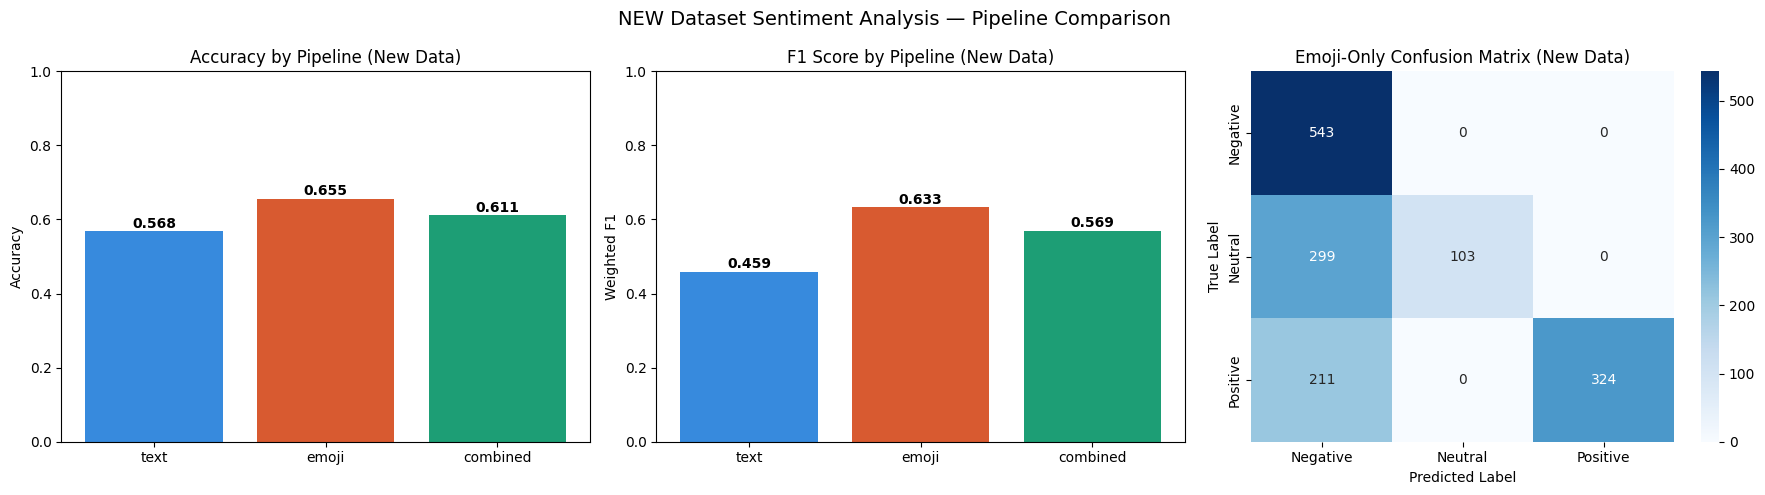

New dataset comparison chart saved locally!


In [ ]:
# ============================================================
# CELL XX: Visualize and compare pipelines on the NEW dataset
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

if 'new_test_results' in globals() and new_test_results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('NEW Dataset Sentiment Analysis — Pipeline Comparison', fontsize=14)

    pipelines  = list(new_test_results.keys())
    accuracies = [new_test_results[p]['accuracy'] for p in pipelines]
    f1_scores  = [new_test_results[p]['f1']       for p in pipelines]
    colors     = ['#378ADD', '#D85A30', '#1D9E75'] # Keep consistent colors

    # Chart 1: Accuracy comparison
    axes[0].bar(pipelines, accuracies, color=colors)
    axes[0].set_title('Accuracy by Pipeline (New Data)')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(accuracies):
        axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

    # Chart 2: F1 Score comparison
    axes[1].bar(pipelines, f1_scores, color=colors)
    axes[1].set_title('F1 Score by Pipeline (New Data)')
    axes[1].set_ylabel('Weighted F1')
    axes[1].set_ylim(0, 1)
    for i, v in enumerate(f1_scores):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

    # Chart 3: Confusion matrix for emoji-only (which was the best performing)
    if 'emoji' in new_test_results:
        cm_new = confusion_matrix(new_test_results['emoji']['labels'], new_test_results['emoji']['preds'])
        sns.heatmap(cm_new, annot=True, fmt='d', ax=axes[2], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
        axes[2].set_title('Emoji-Only Confusion Matrix (New Data)')
        axes[2].set_ylabel('True Label')
        axes[2].set_xlabel('Predicted Label')

    plt.tight_layout()
    # You might want to save this with a different name to distinguish from previous one
    plt.savefig(SAVE_PATH + 'new_dataset_comparison_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("New dataset comparison chart saved locally!")
else:
    print("No new test results to plot. Please complete evaluation on the new dataset first.")

### Evaluation on New Dataset: `emoji_sentiment_dataset.csv`

In [ ]:
print("Loading the new dataset: /content/emoji_sentiment_dataset.csv...")

new_csv_path_2 = '/content/emoji_sentiment_dataset.csv'
df_new_test_raw_2 = pd.read_csv(new_csv_path_2)

print("First 5 records of the new raw dataset:")
display(df_new_test_raw_2.head())

print(f"Total records in new raw dataset: {len(df_new_test_raw_2)}")

Loading the new dataset: /content/emoji_sentiment_dataset.csv...
First 5 records of the new raw dataset:


,sentence,sentiment
0,The museum is closed on Mondays. 🏛️📅,Neutral
1,We are going to the cinema at 7 PM. 🎟️🍿📅,Neutral
2,The hotel room was dirty and small. 🏨🧹👎,Negative
3,This pizza is absolutely delicious! 🍕😋👌,Positive
4,I love the sleek design of this laptop. 💻💎😍,Positive


Total records in new raw dataset: 40000


In [ ]:
# ============================================================
# Preprocess the new test dataset
# ============================================================

# The raw dataset has 'sentence' and 'sentiment' columns.
# Rename 'sentence' to 'comment' first to match the expected 'comment' in rename_dict.
df_new_test_2 = df_new_test_raw_2.rename(columns={'sentence': 'comment', 'sentiment': 'sentiment'})

# Apply existing renaming and sentiment mapping
# The 'rename_dict' and 'sentiment_map' should be available from Cell 5

if 'label' not in df_new_test_2.columns:
  df_new_test_2 = df_new_test_2.rename(columns=rename_dict)

if 'label' in df_new_test_2.columns and df_new_test_2['label'].dtype == object:
    df_new_test_2['label'] = df_new_test_2['label'].str.strip().str.title().map(sentiment_map)

# Drop rows with any missing values in 'text' or 'label'
df_new_test_2 = df_new_test_2.dropna(subset=['text', 'label'])
df_new_test_2['label'] = df_new_test_2['label'].astype(int)

print("Processing new test dataset...")
df_new_test_2 = process_df(df_new_test_2.copy())

print("New test dataset processed successfully!")
display(df_new_test_2.head())
print(f"Total records in new processed dataset: {len(df_new_test_2)}")

Processing new test dataset...
New test dataset processed successfully!


,raw_text,text_only,emoji_only,combined,label
0,The museum is closed on Mondays. 🏛️📅,The museum is closed on Mondays.,:classical_building: :calendar:,The museum is closed on Mondays. 🏛️📅,1
1,We are going to the cinema at 7 PM. 🎟️🍿📅,We are going to the cinema at 7 PM.,:admission_tickets: :popcorn: :calendar:,We are going to the cinema at 7 PM. 🎟️🍿📅,1
2,The hotel room was dirty and small. 🏨🧹👎,The hotel room was dirty and small.,:hotel: :broom: :thumbs_down:,The hotel room was dirty and small. 🏨🧹👎,0
3,This pizza is absolutely delicious! 🍕😋👌,This pizza is absolutely delicious!,:pizza: :face_savoring_food: :OK_hand:,This pizza is absolutely delicious! 🍕😋👌,2
4,I love the sleek design of this laptop. 💻💎😍,I love the sleek design of this laptop.,:laptop: :gem_stone: :smiling_face_with_heart-...,I love the sleek design of this laptop. 💻💎😍,2


Total records in new processed dataset: 40000


In [ ]:
# ============================================================
# Create DataLoaders for the new test dataset
# ============================================================

new_test_text_loader_2  = DataLoader(TextDataset(df_new_test_2),    batch_size=BATCH_SIZE)
new_test_emoji_loader_2 = DataLoader(EmojiDataset(df_new_test_2),   batch_size=BATCH_SIZE)
new_test_comb_loader_2  = DataLoader(CombinedDataset(df_new_test_2), batch_size=BATCH_SIZE)

print("DataLoaders for new test dataset created successfully!")

DataLoaders for new test dataset created successfully!


In [ ]:
# ============================================================
# Evaluate trained models on the new test dataset
# ============================================================

new_test_results_2 = {}

# Ensure models are initialized (if cell 10 was interrupted)
if 'text_model' not in globals():
    print("Re-initializing model structures for evaluation...")
    text_model  = TextSentimentModel().to(DEVICE)
    emoji_model = EmojiSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)
    comb_model  = CombinedSentimentModel(EMOJI_VOCAB_SIZE).to(DEVICE)

for pipeline, model, test_loader in [
    ('text',     text_model,  new_test_text_loader_2),
    ('emoji',    emoji_model, new_test_emoji_loader_2),
    ('combined', comb_model,  new_test_comb_loader_2),
]:
    try:
        model_path = SAVE_PATH + f'best_{pipeline}_model.pth'
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))

        acc, f1, _, preds, labels = evaluate(model, test_loader, pipeline)
        new_test_results_2[pipeline] = {
            'accuracy': acc, 'f1': f1,
            'preds': preds, 'labels': labels
        }

        print(f"\n{'='*40}")
        print(f"Pipeline: {pipeline.upper()} — NEW Dataset 2 Test Results")
        print(f"{'='*40}")
        print(f"Accuracy : {acc:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print(classification_report(labels, preds, target_names=CLASS_NAMES))
    except FileNotFoundError:
        print(f"Warning: Could not find saved model at {model_path}. Please ensure Cell 12 finished training.")


Pipeline: TEXT — NEW Dataset 2 Test Results
Accuracy : 0.6116
F1 Score : 0.6067
              precision    recall  f1-score   support

    Negative       0.52      0.64      0.57     13417
     Neutral       0.68      0.76      0.71     13315
    Positive       0.68      0.44      0.54     13268

    accuracy                           0.61     40000
   macro avg       0.63      0.61      0.61     40000
weighted avg       0.63      0.61      0.61     40000


Pipeline: EMOJI — NEW Dataset 2 Test Results
Accuracy : 0.3759
F1 Score : 0.2495
              precision    recall  f1-score   support

    Negative       0.35      1.00      0.52     13417
     Neutral       1.00      0.04      0.08     13315
    Positive       1.00      0.08      0.15     13268

    accuracy                           0.38     40000
   macro avg       0.78      0.37      0.25     40000
weighted avg       0.78      0.38      0.25     40000


Pipeline: COMBINED — NEW Dataset 2 Test Results
Accuracy : 0.5473
F1 Score

In [ ]:
# ============================================================
# Compare results on the new test dataset
# ============================================================
if 'new_test_results_2' in globals() and new_test_results_2:
    current_pipelines = list(new_test_results_2.keys())
    print("\n" + "="*65)
    print("       NEW DATASET 2 TEST RESULTS SUMMARY")
    print("="*65)
    print(f"{'Pipeline':<12} {'Accuracy':>10} {'F1 Score':>10} {'Winner?':>10}")
    print("-"*65)

    best_f1 = max(new_test_results_2[p]['f1'] for p in current_pipelines)

    for p in current_pipelines:
        acc = new_test_results_2[p]['accuracy']
        f1  = new_test_results_2[p]['f1']
        tag = " <-- BEST" if f1 == best_f1 else ""
        print(f"{p:<12} {acc:>10.4f} {f1:>10.4f}{tag}")

    print("="*65)
else:
    print("No new test results available. Please ensure evaluation on the new dataset completed.")


       NEW DATASET 2 TEST RESULTS SUMMARY
Pipeline       Accuracy   F1 Score    Winner?
-----------------------------------------------------------------
text             0.6116     0.6067 <-- BEST
emoji            0.3759     0.2495
combined         0.5473     0.5204


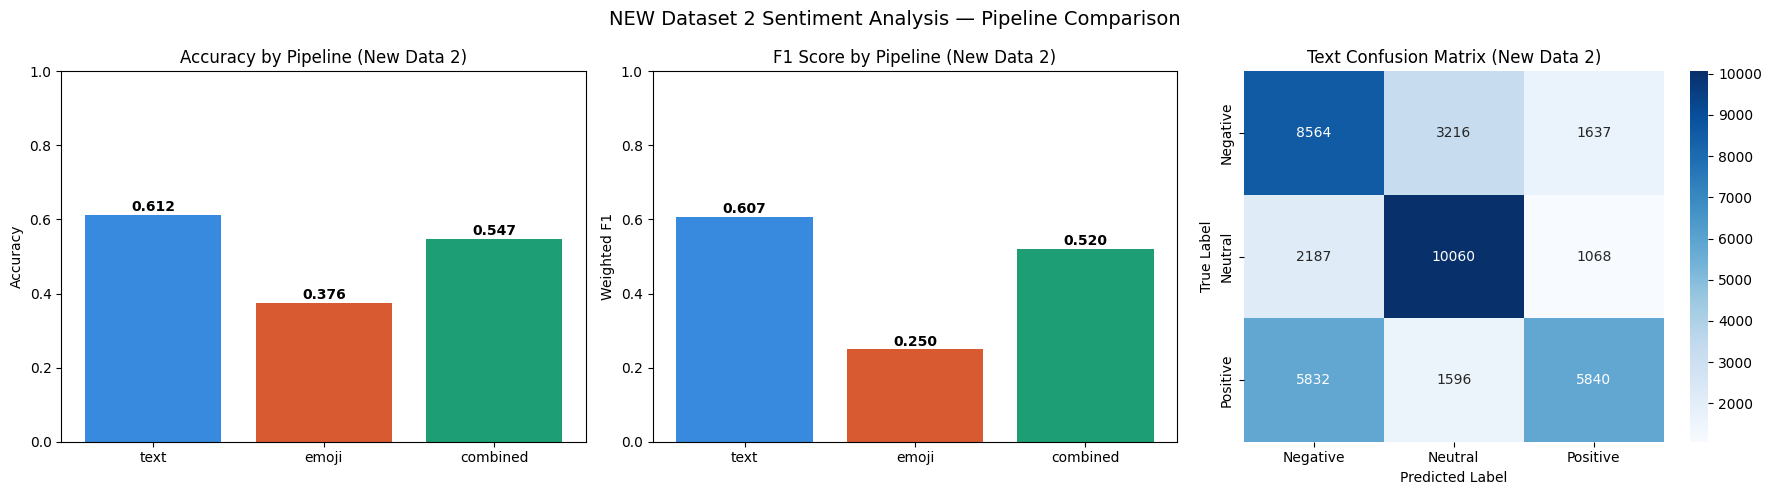

New dataset 2 comparison chart saved locally!


In [ ]:
# ============================================================
# Visualize and compare pipelines on the NEW dataset
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

if 'new_test_results_2' in globals() and new_test_results_2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('NEW Dataset 2 Sentiment Analysis — Pipeline Comparison', fontsize=14)

    pipelines  = list(new_test_results_2.keys())
    accuracies = [new_test_results_2[p]['accuracy'] for p in pipelines]
    f1_scores  = [new_test_results_2[p]['f1']       for p in pipelines]
    colors     = ['#378ADD', '#D85A30', '#1D9E75'] # Keep consistent colors

    # Chart 1: Accuracy comparison
    axes[0].bar(pipelines, accuracies, color=colors)
    axes[0].set_title('Accuracy by Pipeline (New Data 2)')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(accuracies):
        axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

    # Chart 2: F1 Score comparison
    axes[1].bar(pipelines, f1_scores, color=colors)
    axes[1].set_title('F1 Score by Pipeline (New Data 2)')
    axes[1].set_ylabel('Weighted F1')
    axes[1].set_ylim(0, 1)
    for i, v in enumerate(f1_scores):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

    # Chart 3: Confusion matrix for emoji-only (which was the best performing in prior tests)
    # We'll use the pipeline that showed the best F1 on this *new* dataset as the one for the confusion matrix
    best_pipeline_name_2 = max(new_test_results_2, key=lambda p: new_test_results_2[p]['f1'])
    if best_pipeline_name_2 in new_test_results_2:
        cm_new_2 = confusion_matrix(new_test_results_2[best_pipeline_name_2]['labels'], new_test_results_2[best_pipeline_name_2]['preds'])
        sns.heatmap(cm_new_2, annot=True, fmt='d', ax=axes[2], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
        axes[2].set_title(f'{best_pipeline_name_2.title()} Confusion Matrix (New Data 2)')
        axes[2].set_ylabel('True Label')
        axes[2].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(SAVE_PATH + 'new_dataset_2_comparison_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("New dataset 2 comparison chart saved locally!")
else:
    print("No new test results for dataset 2 to plot. Please complete evaluation first.")